① randomforest
- 조금씩 다른 여러 결정트리의 묶음
- 각각 결정트리는 예측을 잘 할 수 있지만 데이터 일부에 과대적합된다.
- 예측을 잘 하지만 서로 다른 부분에 과대적합된 트리를 묶어 평균을 채택하면 과대적합을 줄일 수 있다.
  * 주요 파라미터
    n_estimators: 랜덤 포레스트에서 결정 트리의 개수를 지정 / 디폴트 10
    max_depth & min_samples_leaf : 결정 트리에서 과적합을 개선하기 위해 사용됨
    min_samples_split

    
② gradientboosting
- 여러 결정트리의 묶음
- 랜덤 포레스트와 달리 순차적으로 결정트리를 만들며 이전 트리의 오차를 보완해간다.
- 얕은 트리를 많이 연결하여 성능이 좋은 최종 모델을 만들어내는 것
  * 주요 파라미터
    loss : 최적화시킬 손실함수 지정
    learning_rate : 각 트리의 기여도를 제한하는 파라미터
    n_estimators : 부스팅 단계를 지정하는 파라미터
    subsample : 개별 기본 학습자를 맞추는데 사용할 샘플의 비율

[randomforest,gradientboosting] 모델링
1. 데이터 전처리 :  LabelEncoding("experience_level", "company_size” 칼럼)/ 나머지는 One-Hot Encoding / 정규화 X
2. 모델 학습 및 평가
3. 튜닝의 끝은 순정
    - 다중공선성 확인..?(더미변수에서 다중공선성은 의미없을수도+트리기반모델은 다중공선성 영향 적음)
    - 이상치 제거
    - feature_importances_로 상관관계 계수 높은 칼럼 제거
4. 하이퍼 파라미터 튜닝
5. 모델 학습 및 평가 again

In [3]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [11]:
# 데이터셋 불러오기
df=pd.read_csv('/Users/bluecloud/Documents/대학/유런/데이터셋/job_clean.csv')
df.head(10)

,job_title,job_category,salary_in_usd,experience_level,employment_type,work_setting,company_location,company_size,job_group,companyLoc_group
0,Data DevOps Engineer,Data Engineering,95012,Mid-level,Full-time,Hybrid,Germany,L,2,etc
1,Data Architect,Data Architecture and Modeling,186000,Senior,Full-time,In-person,United States,M,2,United States
2,Data Architect,Data Architecture and Modeling,81800,Senior,Full-time,In-person,United States,M,2,United States
3,Data Scientist,Data Science and Research,212000,Senior,Full-time,In-person,United States,M,2,United States
4,Data Scientist,Data Science and Research,93300,Senior,Full-time,In-person,United States,M,2,United States
5,Data Scientist,Data Science and Research,130000,Senior,Full-time,Remote,United States,M,2,United States
6,Data Scientist,Data Science and Research,100000,Senior,Full-time,Remote,United States,M,2,United States
7,Machine Learning Researcher,Machine Learning and AI,224400,Mid-level,Full-time,In-person,United States,M,2,United States
8,Machine Learning Researcher,Machine Learning and AI,138700,Mid-level,Full-time,In-person,United States,M,2,United States
9,Data Engineer,Data Engineering,210000,Executive,Full-time,Remote,United States,M,2,United States


# 1. 데이터 전처리
### 1-1. 라벨인코딩
- 참고 https://sungkee-book.tistory.com/34

In [13]:
# 순서 꼬임 이슈로 LabelEncoding이 아닌 map으로 인코딩
# 해당 라벨인코딩 순서
experience_order = {'Entry-level' : 0, 'Mid-level' : 1, 'Senior' : 2, 'Executive' : 3}
company_size_order = {'S' : 0, 'M': 1, 'L' : 2}

# 적용 
df['experience_level']=df['experience_level'].map(experience_order)
df['company_size']=df['company_size'].map(company_size_order)

df.head(10)

,job_title,job_category,salary_in_usd,experience_level,employment_type,work_setting,company_location,company_size,job_group,companyLoc_group
0,Data DevOps Engineer,Data Engineering,95012,1,Full-time,Hybrid,Germany,2,2,etc
1,Data Architect,Data Architecture and Modeling,186000,2,Full-time,In-person,United States,1,2,United States
2,Data Architect,Data Architecture and Modeling,81800,2,Full-time,In-person,United States,1,2,United States
3,Data Scientist,Data Science and Research,212000,2,Full-time,In-person,United States,1,2,United States
4,Data Scientist,Data Science and Research,93300,2,Full-time,In-person,United States,1,2,United States
5,Data Scientist,Data Science and Research,130000,2,Full-time,Remote,United States,1,2,United States
6,Data Scientist,Data Science and Research,100000,2,Full-time,Remote,United States,1,2,United States
7,Machine Learning Researcher,Machine Learning and AI,224400,1,Full-time,In-person,United States,1,2,United States
8,Machine Learning Researcher,Machine Learning and AI,138700,1,Full-time,In-person,United States,1,2,United States
9,Data Engineer,Data Engineering,210000,3,Full-time,Remote,United States,1,2,United States


### 1-2.원핫인코딩

In [15]:
df.shape

(7453, 10)

In [17]:
# 원-핫 인코딩 적용할 피처
ohe_features = ["job_group","job_title", "job_category", "employment_type", "work_setting", "company_location","companyLoc_group"]
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(df[ohe_features])
X_ohe = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(ohe_features))

In [19]:
#원래 데이터 프레임과 결합
#dropfirst하기
df=df.drop(ohe_features,axis=1)
df=pd.concat([df,X_ohe],axis=1)

In [21]:
df.shape

(7453, 186)

In [23]:
df.head(10)

,salary_in_usd,experience_level,company_size,job_group_0,job_group_1,job_group_2,job_title_AI Architect,job_title_AI Developer,job_title_AI Engineer,job_title_AI Programmer,...,company_location_Sweden,company_location_Switzerland,company_location_Turkey,company_location_Ukraine,company_location_United Kingdom,company_location_United States,companyLoc_group_Canada,companyLoc_group_United Kingdom,companyLoc_group_United States,companyLoc_group_etc
0,95012,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,186000,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,81800,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,212000,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,93300,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5,130000,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6,100000,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7,224400,1,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
8,138700,1,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
9,210000,3,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


# 2. 모델 학습 및 평가

### 2-1. 데이터 분할

In [25]:
y=df['salary_in_usd']
X=df.drop('salary_in_usd',axis=1,inplace=False)

#데이터 분할 8:2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156)

### 2-2. 모델 학습 및 평가 함수

In [79]:
# 모델 학습 및 평가 함수
def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return {"MAE": mae, "MSE":mse,"RMSE": rmse, "R2 Score": r2}

### 2-3. 모델별 평가 수행

In [81]:
rf=RandomForestRegressor(random_state=42)
gb=GradientBoostingRegressor(random_state=42)

rf_results=train_and_evaluate(rf, X_train, X_test, y_train, y_test)
gb_results=train_and_evaluate(gb, X_train, X_test, y_train, y_test)

print("랜덤 포레스트 결과",rf_results)
print("그래디언트부스트 결과",gb_results)

랜덤 포레스트 결과 {'MAE': 38392.007308671644, 'MSE': 2348973276.2795506, 'RMSE': 48466.20757063163, 'R2 Score': 0.35205973843300054}
그래디언트부스트 결과 {'MAE': 38933.35706049112, 'MSE': 2367798652.898577, 'RMSE': 48660.03136968345, 'R2 Score': 0.34686695076963936}


# 3. 튜닝의 끝은 순정

### 3-1. 다중공선성 확인

In [122]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# 다중공선성 확인 (VIF 계산)
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

vif_df = calculate_vif(X)
print("VIF values:")
print(vif_df.sort_values(by='VIF', ascending=False))

VIF values:
                                            Feature         VIF
159                      company_location_Lithuania         inf
106               job_title_Principal Data Engineer         inf
105                    job_title_Power BI Developer         inf
103           job_title_Machine Learning Specialist         inf
98   job_title_Machine Learning Operations Engineer         inf
..                                              ...         ...
4                                       job_group_2  546.195541
180                  company_location_United States  301.499028
127                       employment_type_Full-time   11.949178
1                                      company_size    1.686834
0                                  experience_level    1.197219

[185 rows x 2 columns]


### 3-2. 다중공선성 제거(VIF>10)

In [ ]:
# 다중공선성이 높은 변수 제거
high_vif_features = vif_df[vif_df["VIF"] > 10]["Feature"].tolist()
X.drop(columns=high_vif_features, inplace=True)

print("VIF values after removal:")
print(calculate_vif(X).sort_values(by='VIF', ascending=False))

In [126]:
X.head()

,experience_level,company_size
0,1,2
1,2,1
2,2,1
3,2,1
4,2,1


애초에 다중공선성이 더미변수에서...의미가...없지...
    >> 없던일로..!

### 3-3. 이상치 제거

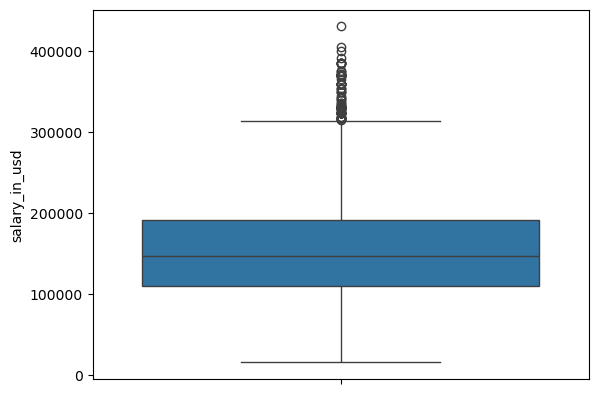

In [31]:
# 이상치 탐색 및 제거
sns.boxplot(y=df["salary_in_usd"])
plt.show()
q1 = df["salary_in_usd"].quantile(0.25)
q3 = df["salary_in_usd"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
df = df[(df["salary_in_usd"] >= lower_bound) & (df["salary_in_usd"] <= upper_bound)]

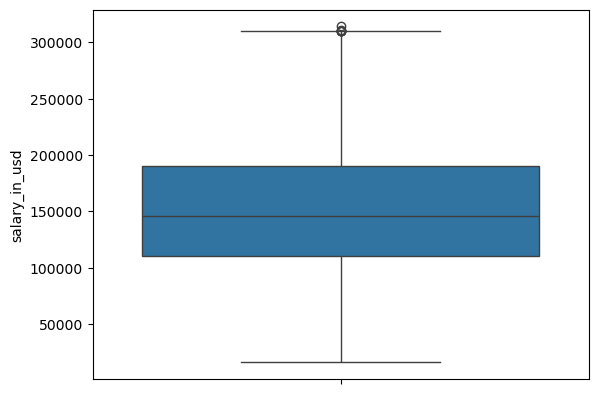

In [33]:
sns.boxplot(y=df["salary_in_usd"])
plt.show()

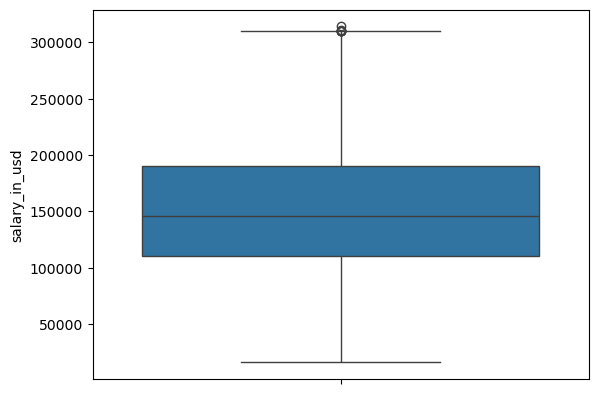

In [39]:
y=df['salary_in_usd']
sns.boxplot(y=y)
plt.show()

In [55]:
#다시 train-test split 적용하기
# 이상치 제거 후, 다시 train-test split 진행
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156)

ValueError: Found input variables with inconsistent numbers of samples: [7453, 7338]

아..y만 이상치 제거해서 인덱스 수가 안 맞겠네...
df다시 불러와서 제거된 인덱스별로 다시 나눠야겠당

In [57]:
X=df.drop('salary_in_usd',axis=1,inplace=False)
y=df['salary_in_usd']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156)

### 3-4.feature_importances로 파악하기

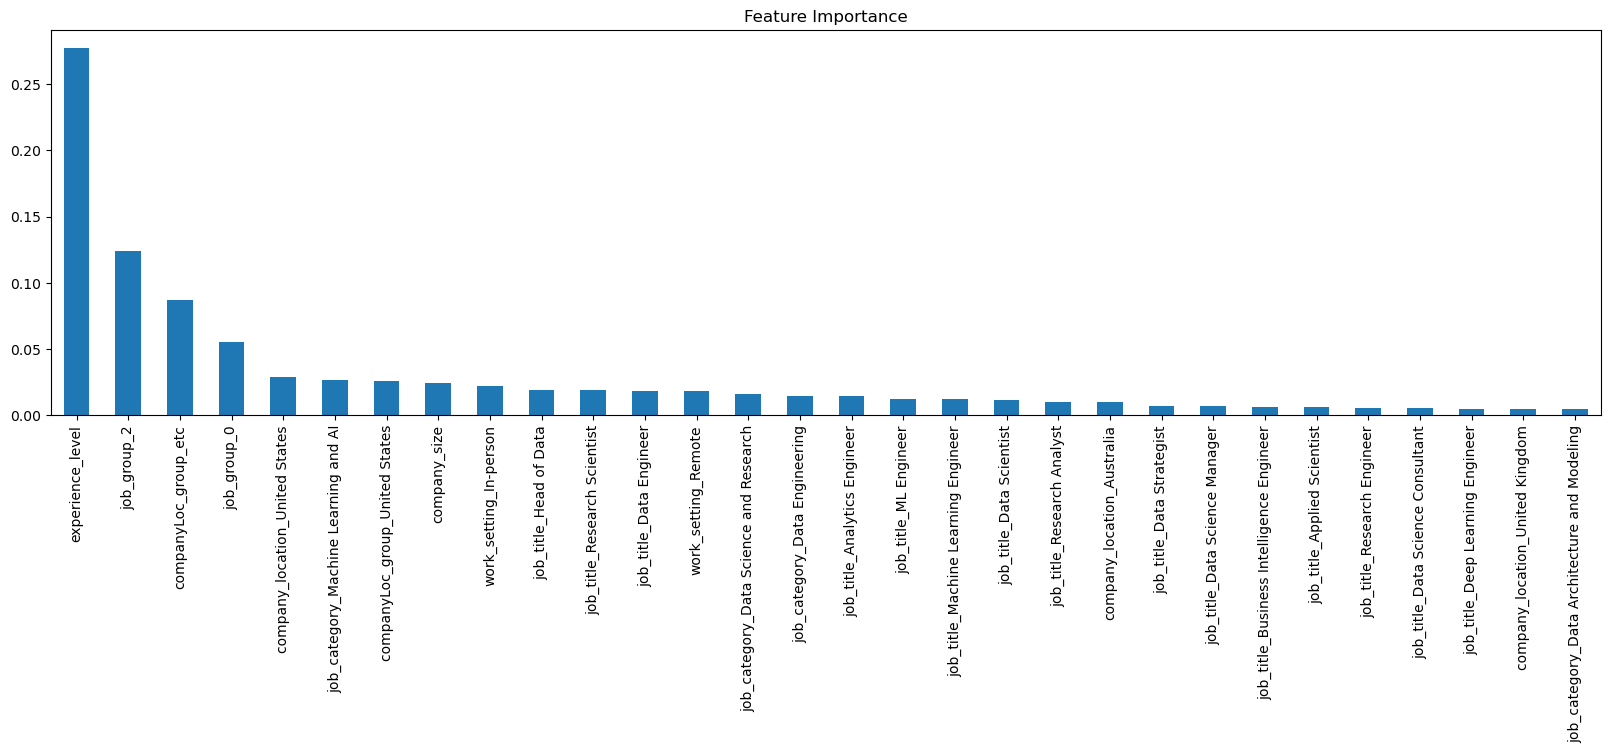

In [41]:
# 랜덤포레스트 중요도 시각화
rf_feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
rf_feature_importances.sort_values(ascending=False)[:30].plot(kind='bar', figsize=(20,5))
plt.title("Feature Importance")
plt.show()

In [43]:
# 랜덤포레스트 피처 중요도
rf_feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
print(rf_feature_importances.sort_values(ascending=False)[:30])

experience_level                               0.277198
job_group_2                                    0.124059
companyLoc_group_etc                           0.086683
job_group_0                                    0.054978
company_location_United States                 0.028811
job_category_Machine Learning and AI           0.026471
companyLoc_group_United States                 0.026078
company_size                                   0.024073
work_setting_In-person                         0.022238
job_title_Head of Data                         0.018620
job_title_Research Scientist                   0.018573
job_title_Data Engineer                        0.018269
work_setting_Remote                            0.017812
job_category_Data Science and Research         0.015950
job_category_Data Engineering                  0.014396
job_title_Analytics Engineer                   0.014109
job_title_ML Engineer                          0.012263
job_title_Machine Learning Engineer            0

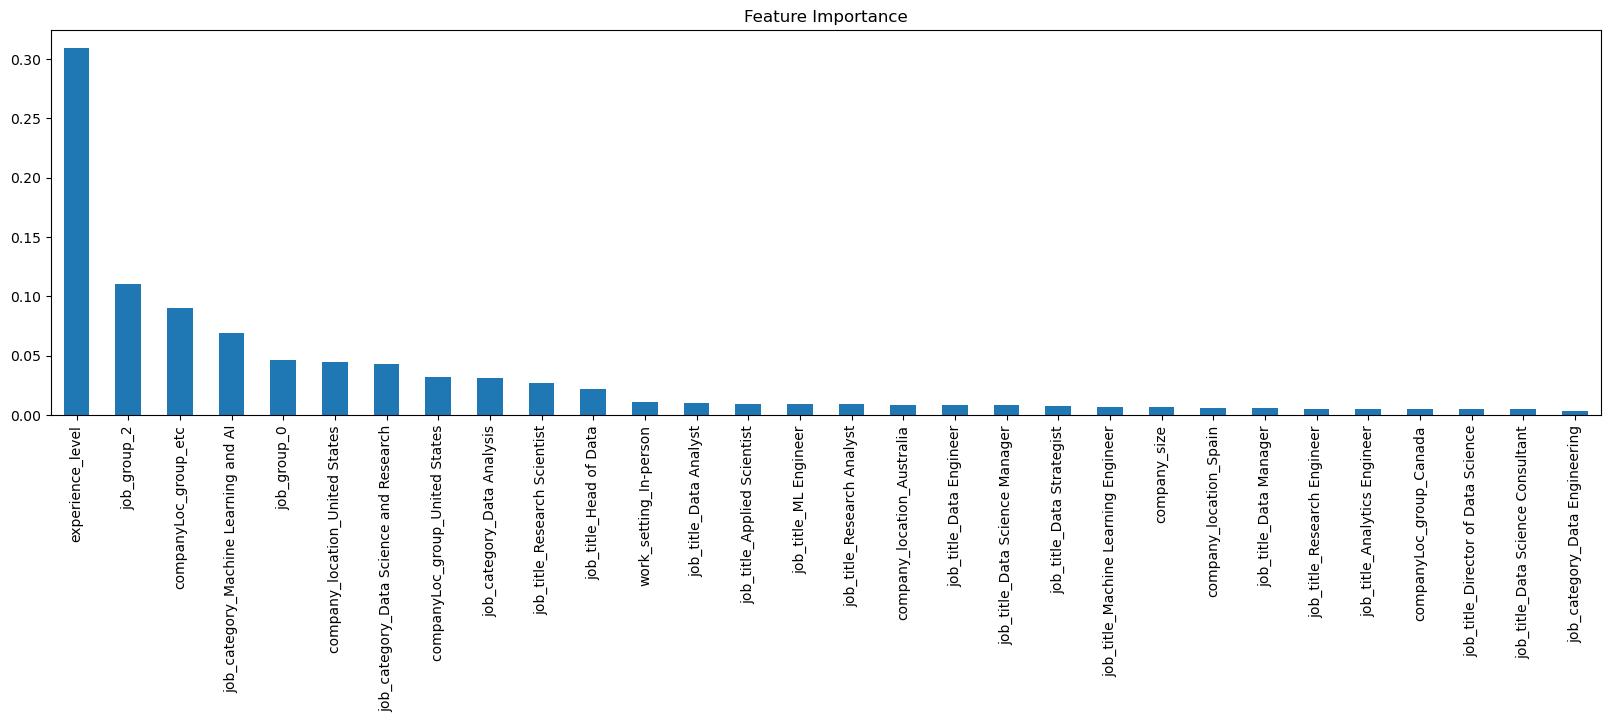

In [45]:
# GradientBoost 중요도 시각화
gb_feature_importances = pd.Series(gb.feature_importances_, index=X_train.columns)
gb_feature_importances.sort_values(ascending=False)[:30].plot(kind='bar', figsize=(20,5))
plt.title("Feature Importance")
plt.show()

In [49]:
# GradientBoost 피처 중요도
gb_feature_importances = pd.Series(gb.feature_importances_, index=X_train.columns)
print(gb_feature_importances.sort_values(ascending=False)[:30])

experience_level                          0.308793
job_group_2                               0.110748
companyLoc_group_etc                      0.090062
job_category_Machine Learning and AI      0.069285
job_group_0                               0.046050
company_location_United States            0.044814
job_category_Data Science and Research    0.042753
companyLoc_group_United States            0.031941
job_category_Data Analysis                0.031286
job_title_Research Scientist              0.026816
job_title_Head of Data                    0.021696
work_setting_In-person                    0.011021
job_title_Data Analyst                    0.010380
job_title_Applied Scientist               0.009708
job_title_ML Engineer                     0.009120
job_title_Research Analyst                0.008900
company_location_Australia                0.008791
job_title_Data Engineer                   0.008422
job_title_Data Science Manager            0.008054
job_title_Data Strategist      

- 적어도 각 모델별 feature_importances_값이 0인거는 제거해야할듯

### 3-5. 각 모델별로 Feature Selection을 따로 진행

In [71]:
# 랜덤포레스트 기반 Feature Selection
important_features_rf = rf_feature_importances[rf_feature_importances > 0].index
X_train_rf = X_train[important_features_rf]
X_test_rf = X_test[important_features_rf]

# 그래디언트 부스팅 기반 Feature Selection
important_features_gb = gb_feature_importances[gb_feature_importances > 0].index
X_train_gb = X_train[important_features_gb]
X_test_gb = X_test[important_features_gb]

### 중간 점검

In [73]:
rf=RandomForestRegressor(random_state=42)
gb=GradientBoostingRegressor(random_state=42)

rf_results_2=train_and_evaluate(rf, X_train_rf, X_test_rf, y_train, y_test)
gb_results_2=train_and_evaluate(gb, X_train_gb, X_test_gb, y_train, y_test)

print("랜덤 포레스트 결과2",rf_results_2)
print("그래디언트부스트 결과2",gb_results_2)

랜덤 포레스트 결과2 {'MAE': 38417.67643583007, 'RMSE': 48500.76686911261, 'R2 Score': 0.351135368833438}
그래디언트부스트 결과2 {'MAE': 38880.18068958775, 'RMSE': 48571.74627145773, 'R2 Score': 0.34923479168813654}


* 1차 결과
  
랜덤 포레스트 결과 {'MAE': 38840.25269714396, 'RMSE': 50861.99406385383, 'R2 Score': 0.3255492151653022}

그래디언트부스트 결과 {'MAE': 39157.62142627965, 'RMSE': 50687.36578401193, 'R2 Score': 0.33017254912024196}

# 4. 하이퍼 파라미터 튜닝

### 4-1. 랜포
- n_jobs=-1 ? : 컴퓨터의 모든 코어 사용

In [77]:
from sklearn.model_selection import GridSearchCV

rf_params={
    "n_estimators": [100, 200, 300],  
    "max_depth": [6, 8, 10, 12,20],  
    "min_samples_split": [2, 5, 8,10],  
    "min_samples_leaf": [1, 2, 4,8]
}

#GridSearchCV 실행
rf_grid=GridSearchCV(rf,param_grid=rf_params,cv=3,n_jobs=-1)
rf_grid.fit(X_train_rf,y_train)

# 최적의 파라미터
print('최적의 하이퍼 파라미터:\n',rf_grid.best_params_)
print('최고 예측 정확도:{0:.4f}'.format(rf_grid.best_score_))

최적의 하이퍼 파라미터:
 {'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
최고 예측 정확도:0.3470


### 4-2.그래디언트

In [83]:

gb_params = {
    "n_estimators": [100, 200, 300],  
    "learning_rate": [0.01, 0.05, 0.1],  
    "max_depth": [3, 5, 7],  
    "subsample": [0.8, 1.0]
}

# GridSearchCV 실행
gb_grid = GridSearchCV(gb, gb_params, cv=3, n_jobs=-1)
gb_grid.fit(X_train_gb, y_train)

# 최적 하이퍼파라미터 
print("최적의 하이퍼 파라미터", gb_grid.best_params_)
print('최고 예측 정확도:{0:.4f}'.format(gb_grid.best_score_))

최적의 하이퍼 파라미터 {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
최고 예측 정확도:0.3510


# 5. 모델 학습 및 평가 again

In [87]:
# 최적 모델 of Rf
best_rf=rf_grid.best_estimator_
rf_results_3=train_and_evaluate(best_rf,X_train_rf, X_test_rf, y_train, y_test)
# 최적 모델 of Gb
best_gb=gb_grid.best_estimator_
gb_results_3=train_and_evaluate(best_gb,X_train_gb, X_test_gb, y_train, y_test)

print("랜덤 포레스트 결과3",rf_results_3)
print("그래디언트부스트 결과3",gb_results_3)

랜덤 포레스트 결과3 {'MAE': 38198.48401744415, 'MSE': 2310440687.798335, 'RMSE': 48067.04367649768, 'R2 Score': 0.3626885589953682}
그래디언트부스트 결과3 {'MAE': 38431.11709846258, 'MSE': 2310182312.5925508, 'RMSE': 48064.3559469234, 'R2 Score': 0.3627598291541686}


- 그렇게 달라진게 없는듯..?